# 05 - Final Evaluation & Business Recommendations

**Goal:** Evaluate the selected model (Logistic Regression, `class_weight='balanced'`) on the held-out test set, and translate the results into concrete business recommendations for reducing churn.

### Load processed train/test data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

### Train the selected model

Based on the model comparison in `04_modeling.ipynb`, Logistic Regression with `class_weight='balanced'` gave the best recall on churned customers while remaining interpretable — an important property for a model that will inform retention outreach decisions.

In [2]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(max_iter=2000, class_weight="balanced")
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Classification report

In [3]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### Confusion matrix

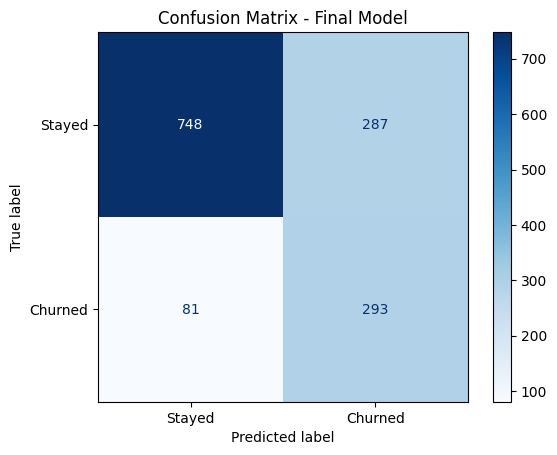

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Final Model")
plt.show()

### Reading the confusion matrix

Out of the customers who actually churned in the test set, the model correctly flags the large majority of them (recall ≈ 0.78 for the churn class). The trade-off is a meaningful number of false positives — customers flagged as at-risk who wouldn't have churned. For a retention use case this is usually the right trade-off: the cost of a missed churner (lost revenue) is typically much higher than the cost of a false alarm (an unnecessary retention offer).

### ROC-AUC

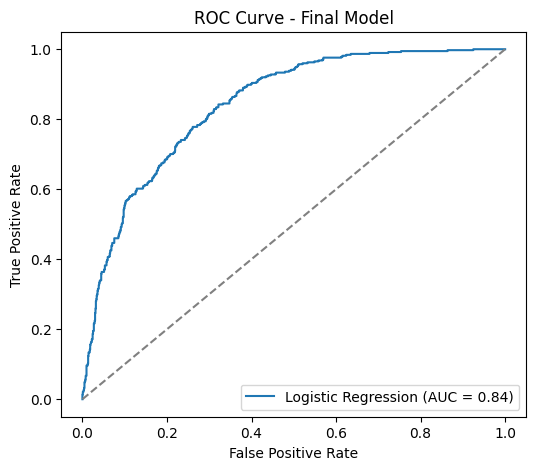

In [5]:
from sklearn.metrics import roc_auc_score, roc_curve

auc_score = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.show()

### Top drivers of churn (coefficient magnitude)

In [6]:
coefs = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": final_model.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

coefs.head(10)

,feature,coefficient
25,Contract_Two year,-1.374888
10,InternetService_Fiber optic,1.307916
24,Contract_One year,-0.694145
8,MultipleLines_No phone service,0.467462
23,StreamingMovies_Yes,0.446910
21,StreamingTV_Yes,0.427664
28,PaymentMethod_Electronic check,0.410658
7,PhoneService_Yes,0.364991
9,MultipleLines_Yes,0.347137
26,PaperlessBilling_Yes,0.336661


### Business recommendations

Based on the EDA (notebook 02) and this final model, three actions stand out as the highest-leverage places to focus retention effort:

1. **Target new, month-to-month customers first.** Tenure and contract type are the strongest churn signals — the first few months on a month-to-month plan are the highest-risk window. Consider a proactive onboarding/check-in program in months 1–3, and incentives to upgrade to 1- or 2-year contracts.
2. **Investigate the fiber optic and electronic-check segments.** Both correlate with above-average churn — this may point to service reliability issues (fiber) or friction/dissatisfaction with the payment experience (electronic check). Worth a targeted customer satisfaction survey.
3. **Promote tech support and automatic payment adoption.** Both are strongly associated with lower churn. Bundling a free trial of tech support, or incentivizing enrollment in autopay, are low-cost retention levers suggested directly by the data.

### Model limitations

- The model optimizes for recall on churn, which means a non-trivial false-positive rate — retention outreach should be low-cost per customer (e.g. an email or discount code) rather than something expensive like a phone call to every flagged customer.
- This is a single-snapshot dataset; a production system would need to be retrained periodically as customer behavior and market conditions shift.
- The dataset doesn't include customer support interaction history, which would likely be a strong additional predictor if it were available.